In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

In [2]:
fact = pd.read_csv("../data/processed/fact_orders.csv")

fact["order_purchase_timestamp"] = pd.to_datetime(
    fact["order_purchase_timestamp"]
)

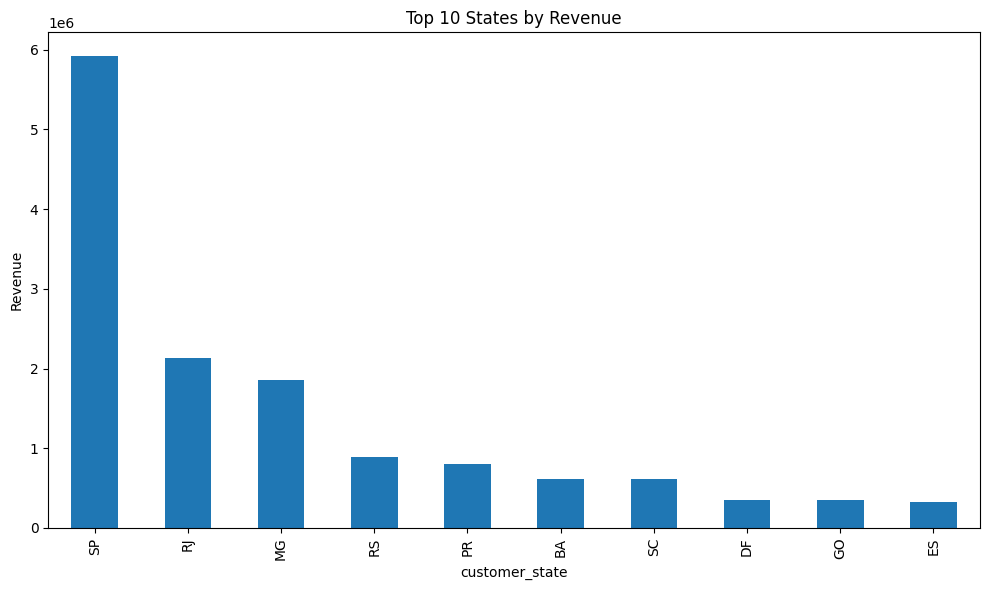

In [3]:
state_revenue = (
    fact.groupby("customer_state")
    ["order_value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

state_revenue.plot(kind="bar")

plt.title("Top 10 States by Revenue")
plt.ylabel("Revenue")
plt.tight_layout()

plt.savefig(
    "../screenshots/revenue_by_state.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

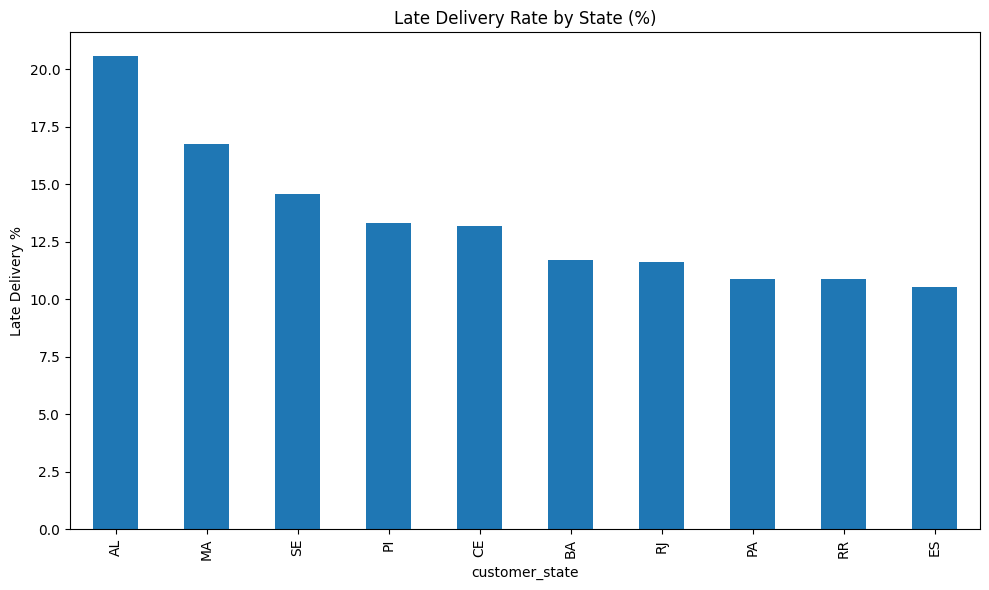

In [4]:
late_rate = (
    fact.groupby("customer_state")
    ["is_late"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

late_rate.plot(kind="bar")

plt.title("Late Delivery Rate by State (%)")
plt.ylabel("Late Delivery %")

plt.tight_layout()

plt.savefig(
    "../screenshots/late_delivery_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

C:\Users\rishu\AppData\Local\Temp\ipykernel_22328\3175995053.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fact.groupby("delivery_bucket")


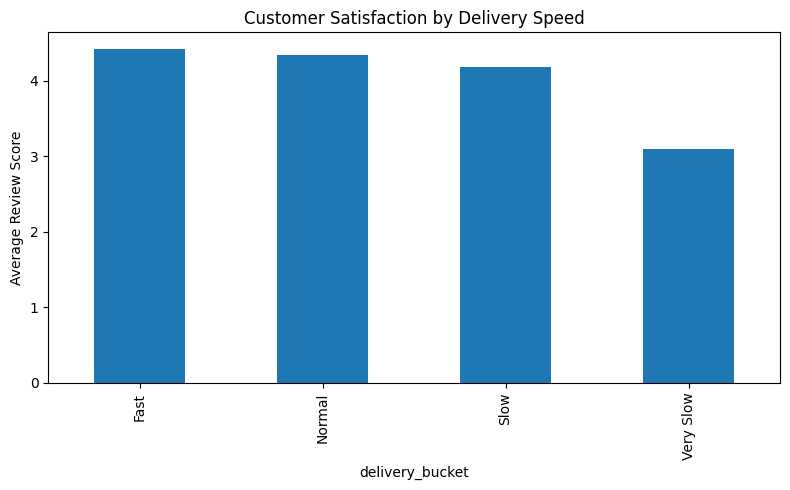

In [5]:
fact["delivery_bucket"] = pd.cut(
    fact["delivery_days"],
    bins=[0,5,10,20,500],
    labels=[
        "Fast",
        "Normal",
        "Slow",
        "Very Slow"
    ]
)

delivery_reviews = (
    fact.groupby("delivery_bucket")
    ["review_score"]
    .mean()
)

plt.figure(figsize=(8,5))

delivery_reviews.plot(kind="bar")

plt.title(
    "Customer Satisfaction by Delivery Speed"
)

plt.ylabel("Average Review Score")

plt.tight_layout()

plt.savefig(
    "../screenshots/delivery_vs_reviews.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

C:\Users\rishu\AppData\Local\Temp\ipykernel_22328\926216374.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


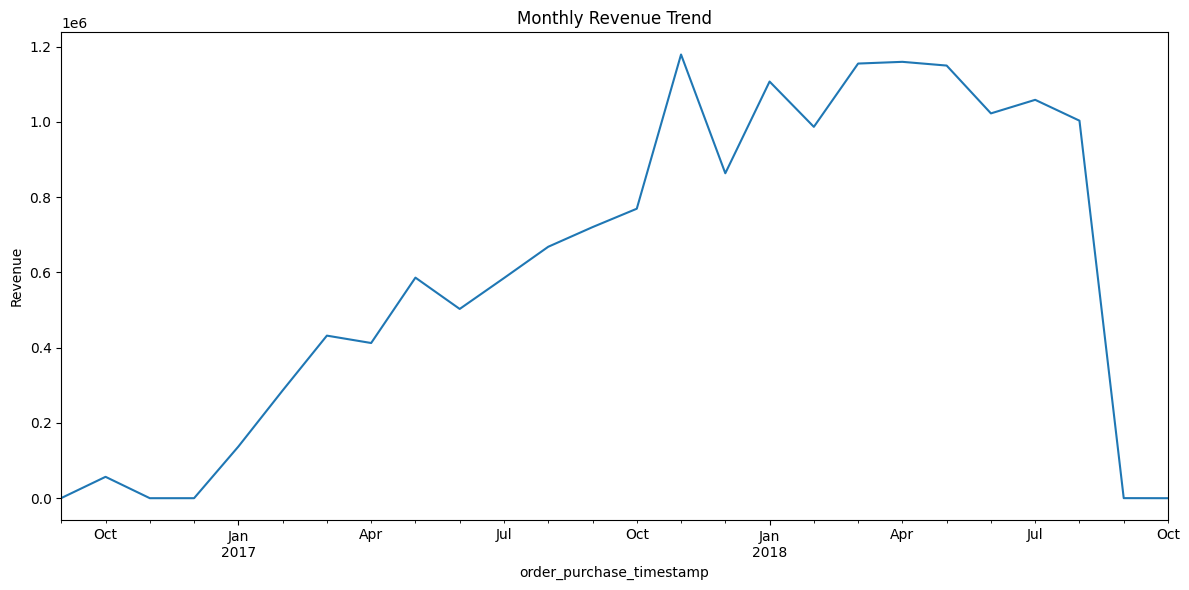

In [6]:
monthly_revenue = (
    fact.set_index(
        "order_purchase_timestamp"
    )
    .resample("M")
    ["order_value"]
    .sum()
)

plt.figure(figsize=(12,6))

monthly_revenue.plot()

plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")

plt.tight_layout()

plt.savefig(
    "../screenshots/monthly_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

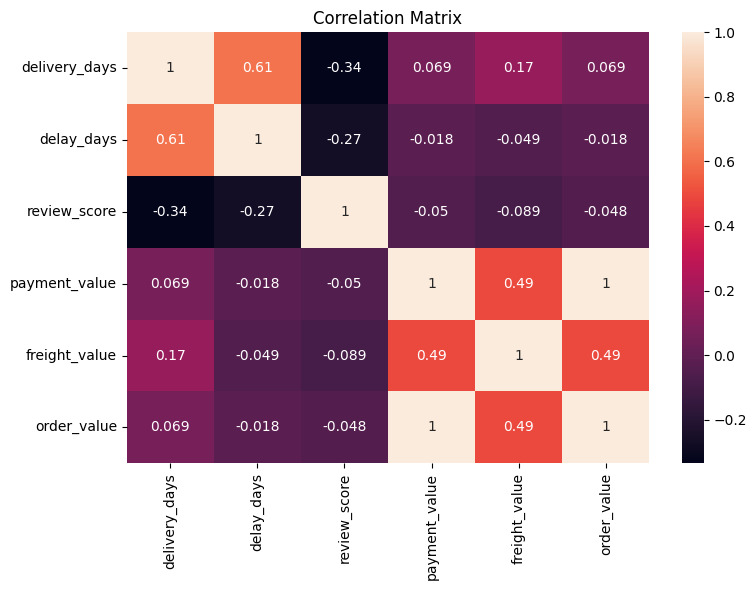

In [7]:
corr = fact[
[
    "delivery_days",
    "delay_days",
    "review_score",
    "payment_value",
    "freight_value",
    "order_value"
]
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.savefig(
    "../screenshots/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()